# Enforcement Patterns

In [ ]:
# Setup

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.enforcement_patterns import *

FIGURES_DIR = "../outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

DATA_DIR = "../data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

# Load df
violations_df_full = pd.read_csv(f"{DATA_DIR}/violations_df_full.csv", low_memory = False)
violations_df_full['violation_date'] = pd.to_datetime(violations_df_full['violation_date'], format = "mixed")
violations_df_full['year'] = violations_df_full['violation_date'].dt.year

DATA_DIR = "../data/raw/council_districts_26"
os.makedirs(DATA_DIR, exist_ok=True)

# Load council district shapefile
nycc = gpd.read_file(f"{DATA_DIR}/nycc.shp")

In [13]:
# Creating separate violation and respondent dataframes for plotting

violations_gdf = gpd.GeoDataFrame(
    violations_df_full,
    geometry = gpd.points_from_xy(violations_df_full['v_matched_lon'], violations_df_full['v_matched_lat']),
    crs = "EPSG:4326"
).to_crs("EPSG:2263")

respondents_gdf = gpd.GeoDataFrame(
    violations_df_full,
    geometry = gpd.points_from_xy(violations_df_full['r_matched_lon'], violations_df_full['r_matched_lat']),
    crs = "EPSG:4326"
).to_crs("EPSG:2263")

# Assigning council districts

violations_gdf = gpd.sjoin(violations_gdf,
                           nycc[['CounDist', 'geometry']],
                           how = "left",
                           predicate = 'within').drop(columns = ['index_right'])

respondents_gdf = gpd.sjoin(respondents_gdf,
                            nycc[['CounDist', 'geometry']],
                            how = "left",
                            predicate = "within").drop(columns = ['index_right'])

In [14]:
# Creating a dataframe aggregated to the council district level

cc_analysis = violations_gdf[['ticket_number', 'CounDist']].groupby('CounDist').agg('count').rename(columns = {'ticket_number': "ticket_count"})

cc_analysis = nycc.merge(
    cc_analysis,
    on = "CounDist",
    how = 'left'
)

**Enforcement Intensity**

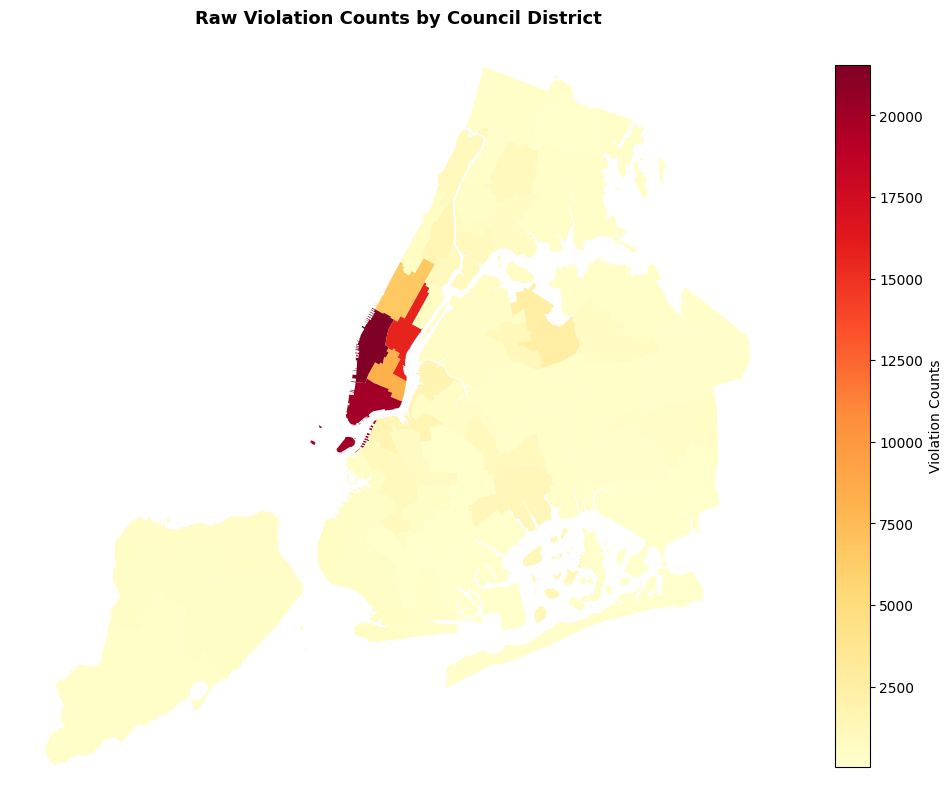

In [15]:
# Plotting raw counts
fig, ax = plt.subplots(figsize=(10, 12))

cc_analysis.plot(
    ax=ax,
    column='ticket_count', cmap="YlOrRd",
    linewidth=0.1,
    legend=True, legend_kwds={'label': 'Violation Counts', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
ax.set_title('Raw Violation Counts by Council District', fontweight='bold', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.show()


# NORMALIZING

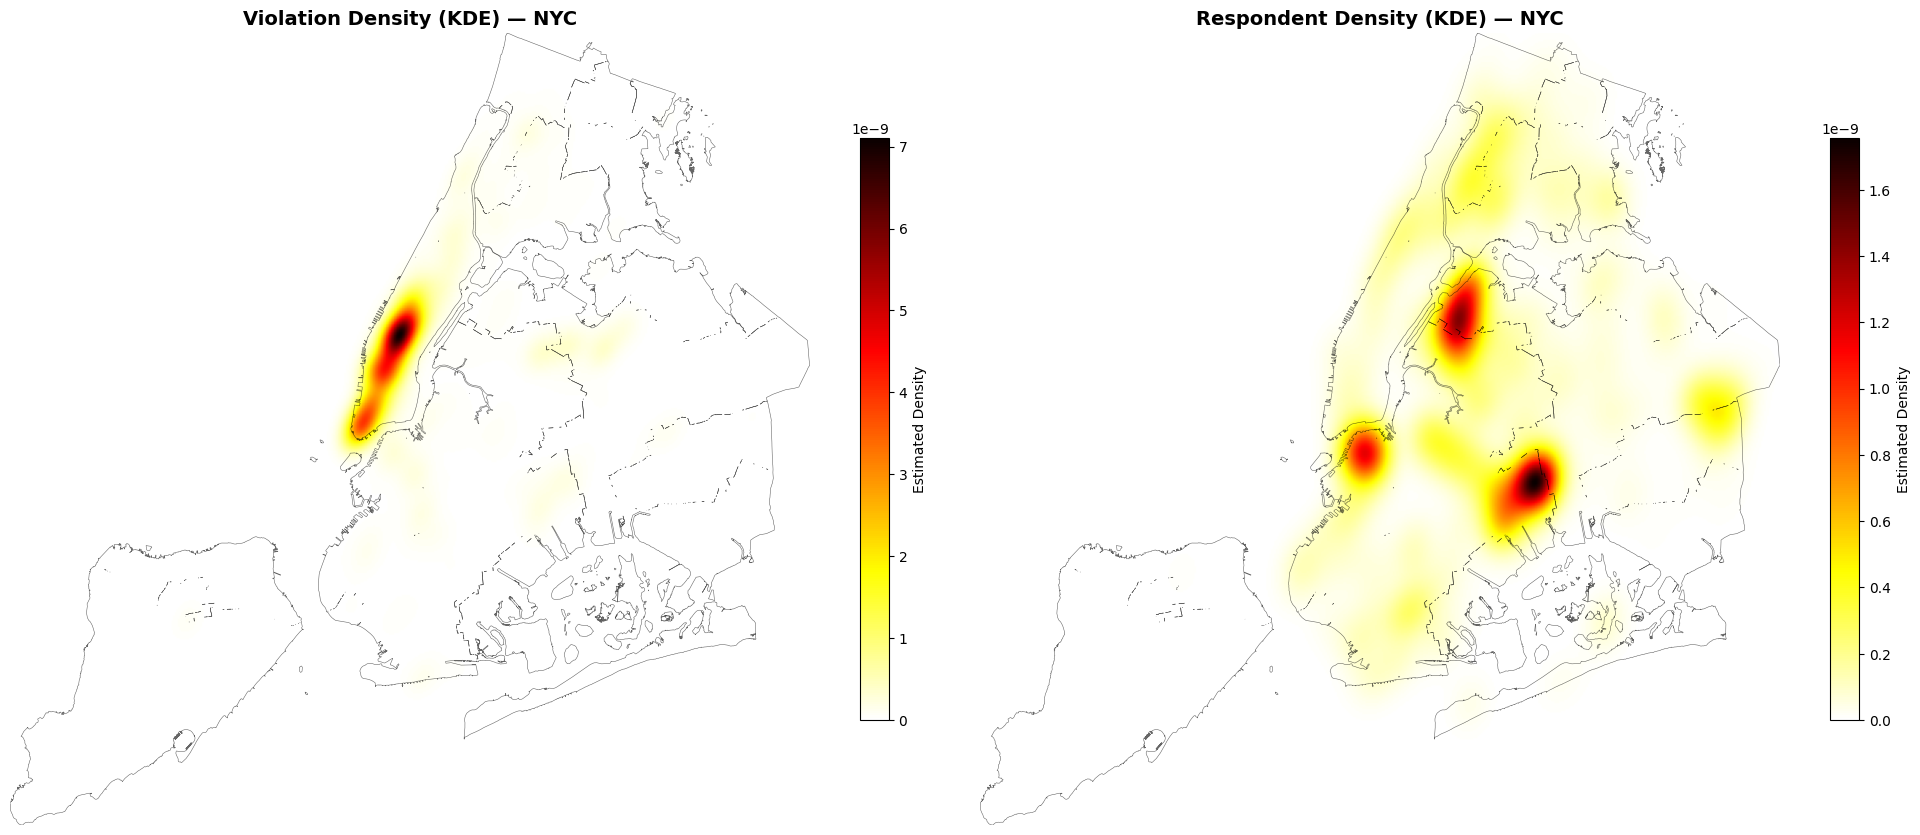

In [20]:
# Kernel Density Estimation Maps on violation points and respondent home addresses

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plot_kde_map(
    violations_gdf,
    boundary_gdf=nycc.dissolve(),
    title='Violation Density (KDE) — NYC',
    ax=axes[0]
)

plot_kde_map(
    respondents_gdf,
    boundary_gdf=nycc.dissolve(),
    title='Respondent Density (KDE) — NYC',
    ax=axes[1]
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/kde_maps.png")
plt.show()

**Fragmentation Patterns**

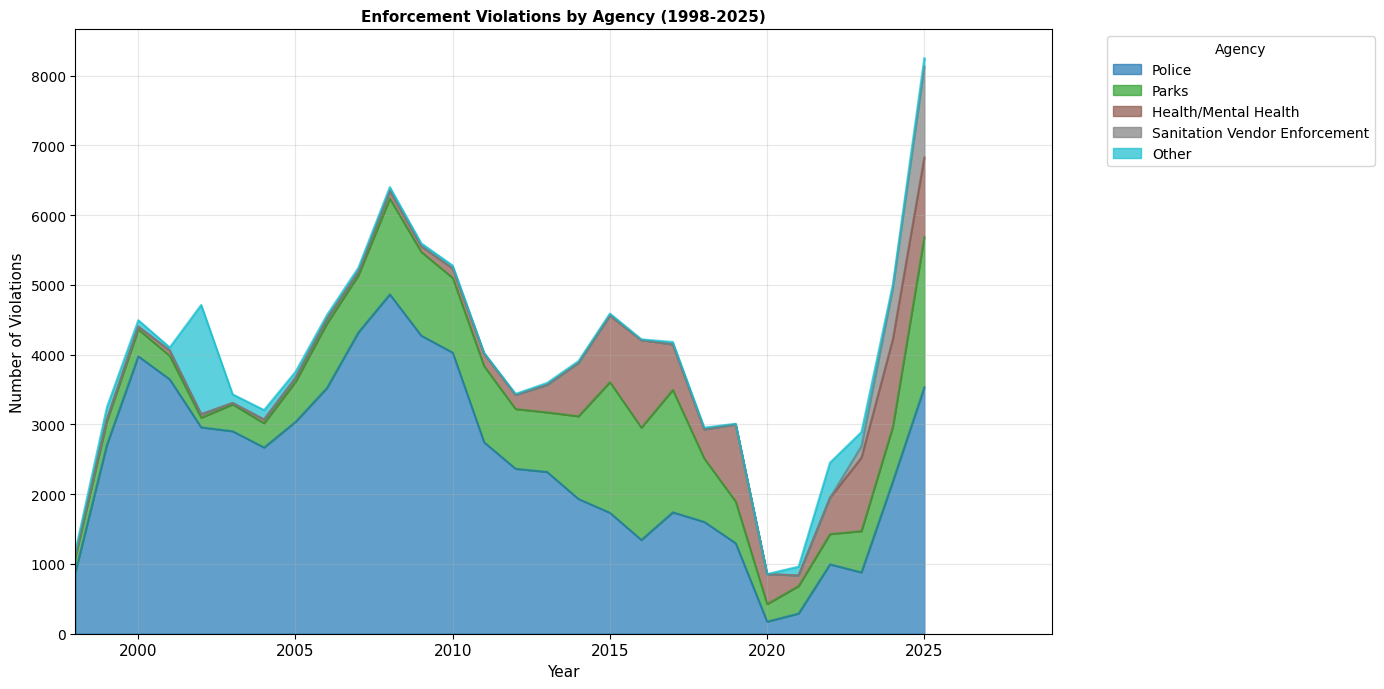

In [21]:
# Breakdown by Agency

# Has the number of each agency issuing violations by year
df_byagency = violations_df_full.groupby(["year", "agency_normalized"]).size().reset_index(name='count')

# Pivot: year as index, agency_normalized as columns
df_wide = df_byagency.pivot_table(
    index='year',
    columns='agency_normalized',
    values='count',
    aggfunc='sum',
    fill_value=0
)

# Identify top 5 agencies by total count, group rest into "Other"
top_4 = df_wide.sum().sort_values(ascending=False).head(4).index.tolist()
df_top = df_wide[top_4].copy()
df_top['Other'] = df_wide.drop(columns=top_4).sum(axis=1)

# Reorder so "Other" is on top of the stack (plotted last)
df_top = df_top[top_4 + ['Other']]

#Set a color scheme to be consistent
tab10 = plt.get_cmap('tab10').colors
color_map = {
    'Police': tab10[0],
    'Parks': tab10[1],
    'Health/Mental Health': tab10[2],
    'Sanitation Vendor Enforcement': tab10[3],
    'Other': tab10[7],   # grayish — feels right for "Other"
}

colors = [color_map.get(col, 'lightgray') for col in df_top.columns]

# Create stacked area chart
fig, ax = plt.subplots(figsize=(14, 7))
df_top.plot(kind='area', stacked=True, alpha=0.7, ax=ax, legend=False, cmap='tab10')

# Give the labels room on the right
ax.set_xlim(df_top.index.min(), df_top.index.max() + (df_top.index.max() - df_top.index.min()) * 0.15)

ax.set_title('Enforcement Violations by Agency (1998-2025)', fontsize=11, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.set_ylabel('Number of Violations', fontsize=11)
plt.legend(title='Agency', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/violations_by_agency_year.png", dpi=150, bbox_inches='tight')
plt.show()

<Figure size 2000x1000 with 0 Axes>

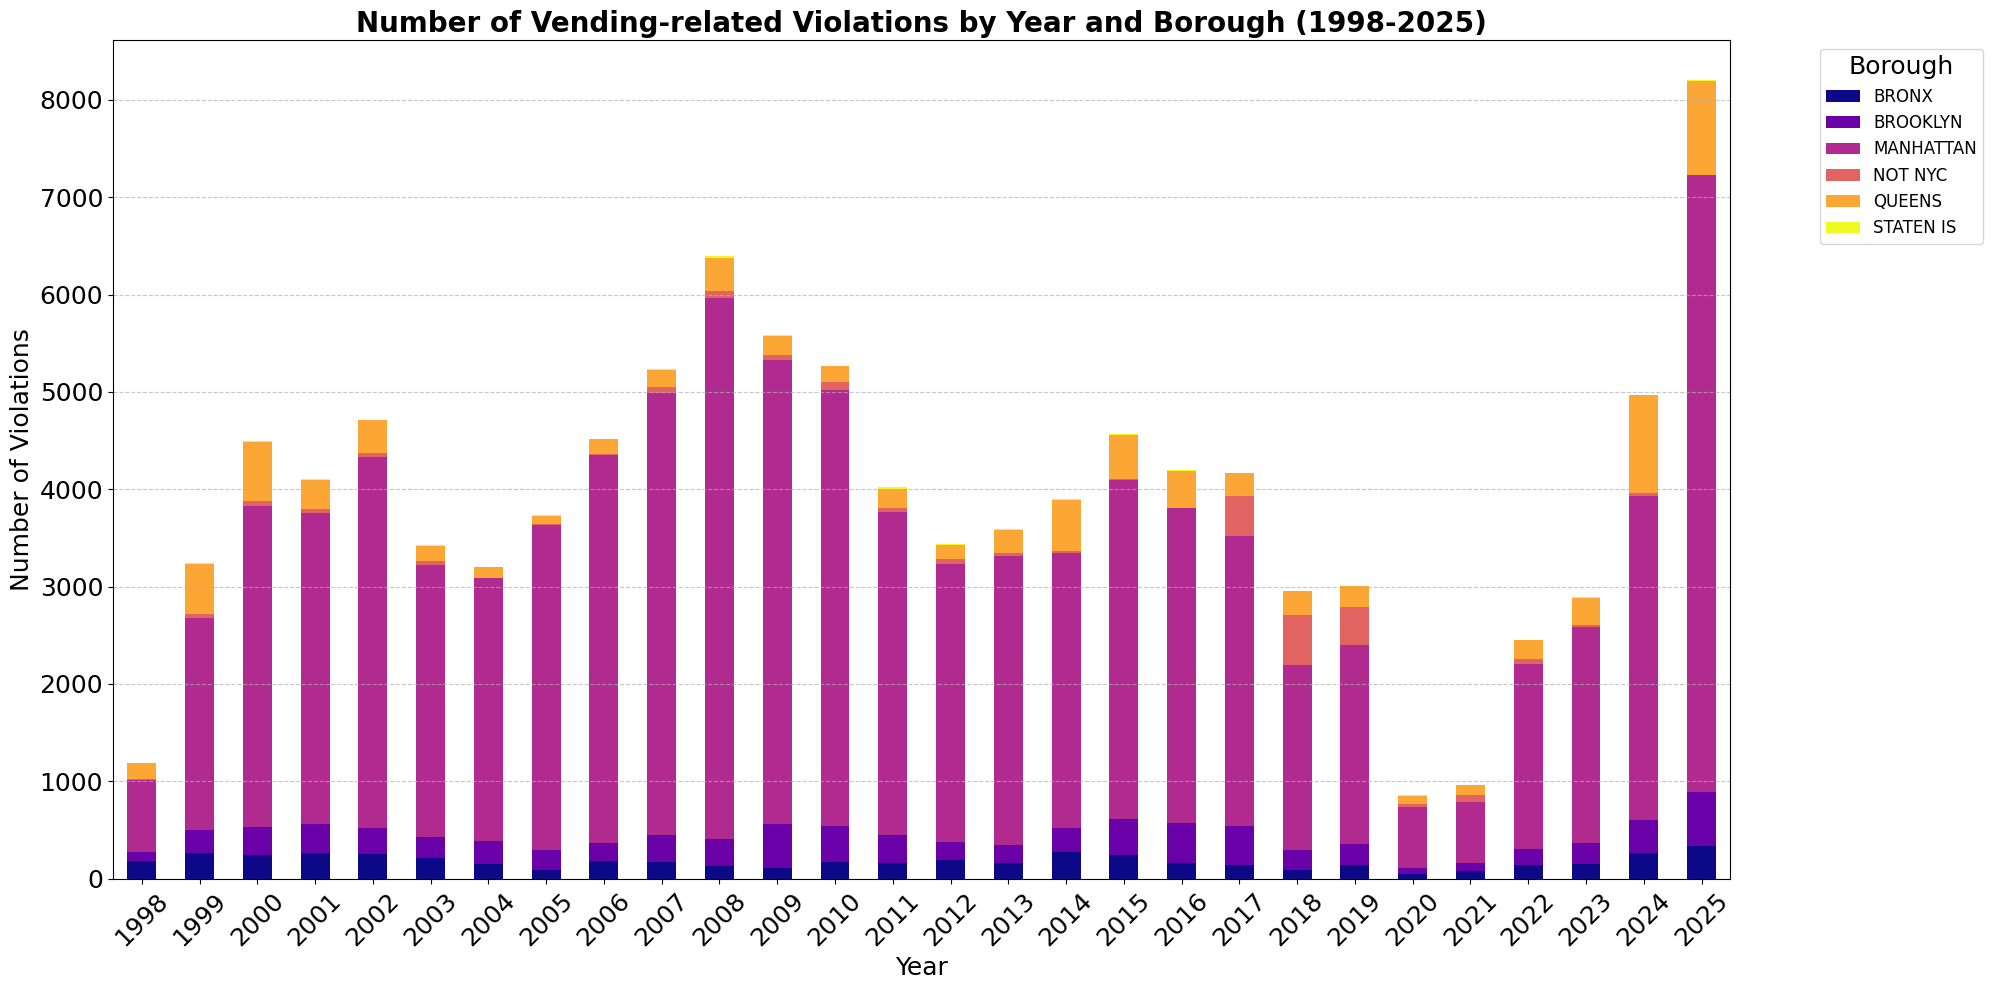

In [22]:
# Breakdown by borough

# Group by year and borough, count violations
borough_counts = violations_df_full.groupby(['year', 'violation_location_borough']).size().unstack(fill_value=0)

# Reindex to include all years in range even if some are missing
all_years = list(range(1998, 2026))
borough_counts = borough_counts.reindex(all_years, fill_value=0)

# Create stacked bar chart
plt.figure(figsize=(20,10))
borough_counts.plot(kind='bar', stacked=True, figsize=(20,10),
                   colormap='plasma')

plt.title("Number of Vending-related Violations by Year and Borough (1998-2025)",
          fontsize=20, fontweight='bold')  # Larger title font
plt.xlabel("Year", fontsize=18)  # Larger x-axis label
plt.ylabel("Number of Violations", fontsize=18)  # Larger y-axis label
plt.xticks(rotation=45, fontsize=18)  # Larger year labels
plt.yticks(fontsize=18)  # Larger y-axis numbers
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=12, title_fontsize=18)  # Larger legend fonts
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/violations_by_borough_year.png", dpi=150, bbox_inches='tight')
plt.show()

**Administration**

* Rudolph W. Giuliani 1994 - 2001
* Michael R. Bloomberg 2002 - 2013
* Bill de Blasio 2014 - 2021
* Eric L. Adams 2022 - 2025
* Zohran Kwame Mamdani 2026 - Present

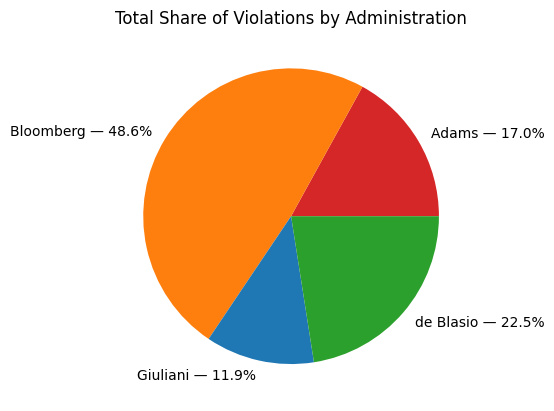

In [24]:
# Assigning administration column

administrations = [
    violations_df_full['year'] < 2002,
    violations_df_full['year'].between(2002, 2013),
    violations_df_full['year'].between(2014, 2021),
    violations_df_full['year'].between(2022, 2025),
    violations_df_full['year'] > 2025
]


values = ["Giuliani", "Bloomberg", "de Blasio", "Adams", "Mamdani"]

violations_df_full['administration'] = np.select(administrations, values, default="unknown")

# Plotting
administration_grouped = violations_df_full.groupby("administration").size()

color_map = {
    'Giuliani': tab10[0],
    'Bloomberg': tab10[1],
    'de Blasio': tab10[2],
    'Adams': tab10[3],
}

total = administration_grouped.sum()
labels = [f"{name} — {count/total*100:.1f}%"
          for name, count in administration_grouped.items()]

colors = [color_map[name] for name in administration_grouped.index]

administration_grouped.plot(
    kind="pie",
    labels=labels,
    colors=colors,
    ylabel="",
    title="Total Share of Violations by Administration"
)

plt.savefig(f"{FIGURES_DIR}/violations_by_administration.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np

In [25]:
DATA_DIR

'../data/raw/council_districts_26'

In [26]:
DATA_DIR = "../data/processed"
violations_df_full.to_csv(f"{DATA_DIR}/violations_df_full.csv")